In [1]:
import numpy as np
import numpy.ma as ma
from admUI import admUI_numpy
import torch

from torch.utils.data import TensorDataset, DataLoader

In [2]:
def get_params():
    lamda_m = np.array([2., 2.])
    lamda_x = np.array([1.])      # Noise to be added to X: shape (d_X,)
    lamda_y = np.array([1.])

    w_x1_vals = np.arange(11) / 10
    w_x2 = 0.5
    w_y1 = 0.5
    w_y2 = 0.5

    return lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2

lamda_m, lamda_x, lamda_y, w_x1_vals, w_x2, w_y1, w_y2 = get_params()
print(w_x1_vals)

[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [3]:
dm = lamda_m.size  # Number of dimensions of M
dx = lamda_x.size
dy = lamda_y.size
print(f"dm: {dm}, dx: {dx}, dy: {dy}")

dm: 2, dx: 1, dy: 1


In [4]:
from pid.utils.estimate import approx_pid_from_cov
from pid.utils.generate import sample_mult_poisson
from pid.utils.distributions import mult_poisson_dist

# We first compute the ground truth PID values for the multivariate Poisson distribution
MASK_THRESH = 1e-8

def pid(p, qstar, ind=1):
    """
    Computes the unique, redundant, synergistic and total information about M
    present in X_`ind` with respect to the other variables, given the optimal
    `q_star` from Bertschinger's definition.

    Here, `p` is the original joint distribution of all variables, where the
    first dimension of p represents M, and the remaining dimensions represent
    X_i, the variables being used in the decomposition.

    `q_star` may be computed using one of the two functions below,
    `compute_qstar` or `compute_qstar_admui`.

    Note: X_i's are 1-indexed, so X_1 is the first X variable. Equivalently,
          `ind` is the index of X_`ind` in *p*.
    """

    # Roll axes so that the variable of interest is always at index 1
    qstar = np.rollaxis(qstar, ind, 1)
    p = np.rollaxis(p, ind, 1)
    # Mask out near-zero values to avoid divide-by-zero and log errors
    qstar = ma.array(qstar, mask=(abs(qstar) < MASK_THRESH))
    p = ma.array(p, mask=(abs(p) < MASK_THRESH))

    # First, compute the unique information
    axes = (0, 1)
    qrest = ma.sum(qstar, axis=axes, keepdims=True)  # q*(x2)
    qstar_rest = qstar / qrest                       # q*(m, x1 | x2)

    qmrest = ma.sum(qstar, axis=1, keepdims=True)    # q*(m, x2)
    qm_rest = qmrest / qrest                         # q*(m | x2)

    qrestx = ma.sum(qstar, axis=0, keepdims=True)    # q*(x1, x2)
    qx_rest = qrestx / qrest                         # q*(x1 | x2)

    uniq_info = ma.sum(qstar * ma.log2(qstar_rest / (qm_rest * qx_rest)))

    # Then, compute redundant information
    axes = tuple(range(2, qstar.ndim))
    qmx = ma.sum(qstar, axis=axes, keepdims=True)    # q*(m, x1)
    axes = tuple(range(1, qstar.ndim))
    qm = ma.sum(qstar, axis=axes, keepdims=True)     # q*(m)
    axes = list(range(qstar.ndim))
    axes.remove(1)
    axes = tuple(axes)
    qx = ma.sum(qstar, axis=axes, keepdims=True)     # q*(x1)
    Imx = ma.sum(qmx * ma.log2(qmx / (qm * qx)))     # I(M ; X1)
    red_info = Imx - uniq_info

    # Alternate way to compute redundant info from p
    #axes = tuple(range(1, p.ndim))
    #pm = ma.sum(p, axis=axes, keepdims=True)
    #axes = tuple(range(2, p.ndim))
    #pmx = ma.sum(p, axis=axes, keepdims=True)
    #axes = list(range(p.ndim))
    #axes.remove(1)
    #axes = tuple(axes)
    #px = ma.sum(p, axis=axes, keepdims=True)
    #Imx = ma.sum(pmx * ma.log2(pmx / (pm * px)))
    #red_info = Imx - uniq_info

    # Finally, synergistic information
    axes = tuple(range(1, p.ndim))
    pm = ma.sum(p, axis=axes, keepdims=True)         # p(m)
    pall = ma.sum(p, axis=0, keepdims=True)          # p(x1, x2)
    Imall_p = ma.sum(p * ma.log2(p / (pm * pall)))   # I_p(M ; (X1, X2))
    Imall_q = ma.sum(qstar * ma.log2(qstar / (qm * qrestx))) # I_q(M ; (X1, X2))
    syn_info = Imall_p - Imall_q

    return (uniq_info, red_info, syn_info, Imall_p)


def compute_qstar_admui(p, M_dim, lamdas, ind=1, maxiter=250, verbose=False):
    """
    Compute the optimal distribution for the bivariate PID of information about
    M contained between X_ind and the other variables, using the iterative
    algorithm given by Banerjee et al. (ISIT 2018).

    Parameters:
        p - np.ndarry
            Joint distribution of (M, X1, X2, ...), each dimension of p
            represents these variables in order
        M_dim - int
                Should be equal to p.shape[0]
        lamdas - not used
        ind - int
              Index to be used as X1 (remaining indices are treated together
              as X2)
        verbose - not used
    """

    p = np.rollaxis(p, ind, 1)
    newshape = p.shape
    p = p.reshape((M_dim, p.shape[1], -1))  # Reshape into a bivariate PID

    pm = p.sum(axis=(1, 2))
    px_m = p.sum(axis=2).T / pm  # p(x1 | m)
    py_m = p.sum(axis=1).T / pm  # p(y | m) - here, `y` is the same as x2

    qstar = admUI_numpy.computeQUI_numpy(px_m, py_m, pm, maxiter=maxiter)
    # In the above, `maxiter` may need to be tuned based on performance

    qstar = qstar.reshape(newshape)  # Reshape back into the original shape
    qstar = np.rollaxis(qstar, 1, ind+1)  # And place X1 in its original index
    return qstar

def gt_pid(lamda_m, w_x, w_y, lamda_x, lamda_y, D):
    p = mult_poisson_dist(lamda_m, w_x, w_y, lamda_x, lamda_y, D=D)
    D = p.shape[0]
    # Compute Bertschinger's PID using the Banerjee et al. package
    p = p.reshape((D**2, D, D))
    qstar = compute_qstar_admui(p, p.shape[0], [], maxiter=10000)
    uix, ri, si, imxy = pid(p, qstar)  # UI corresponds to X
    uiy = imxy - uix - ri - si

    ret = (imxy, imxy, uix, uiy, ri, si)
    return ret

In [5]:
def covariance_to_correlation(covariance_matrix):
    covariance_matrix = np.array(covariance_matrix)

    if covariance_matrix.shape[0] != covariance_matrix.shape[1]:
        raise ValueError("Covariance matrix must be square")

    if not np.allclose(covariance_matrix, covariance_matrix.T):
        raise ValueError("Covariance matrix must be symmetric")

    std_devs = np.sqrt(np.diag(covariance_matrix))
    outer_std = np.outer(std_devs, std_devs)
    correlation_matrix = covariance_matrix / outer_std
    np.fill_diagonal(correlation_matrix, 1.0)

    return correlation_matrix

In [6]:
w_x = np.array([[0.5, 0.5]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[0.5, 0.5]])
m, x, y = sample_mult_poisson(100, lamda_m, w_x, w_y, lamda_x, lamda_y)
print(m.shape, x.shape, y.shape)

(2, 100) (1, 100) (1, 100)


In [7]:
from pid.optimizers import exact_gauss_tilde_pid, mmi_pid

n = 100000  # Sample size
D = 10    # Support of distribution in each dimension
pid_defn_names = ['tilde', 'delta', 'mmi']
pid_defns = [exact_gauss_tilde_pid, approx_pid_from_cov, mmi_pid]

w_x1 = w_x1_vals[0]
print(f"\nw_x1: {w_x1}")
w_x = np.array([[w_x1, w_x2]])  # Binomial thinning weights: shape (dx, dm)
w_y = np.array([[w_y1, w_y2]])

m, x, y = sample_mult_poisson(n, lamda_m, w_x, w_y, lamda_x, lamda_y)  # Shape: (d, n)
mxy = np.vstack((m, x, y))
cov = np.corrcoef(mxy)  # Shape: (dm+dx+dy, dm+dx+dy)

###### ground truth (time-consuming) ######
gt = False  # Set to True to compute the ground truth PID using the iterative method
if gt:
    ret = gt_pid(lamda_m, w_x, w_y, lamda_x, lamda_y, D)
    imxy, uix, uiy, ri, si = ret[2], *ret[-4:]
    norm = uix + uiy + ri + si
    print(f"truth: R: {ri/norm}, U1: {uix/norm}, U2: {uiy/norm}, S: {si/norm}")

###### tilde, delta, mmi pid ######
for pid_name, pid_defn in zip(pid_defn_names, pid_defns):
    ret = pid_defn(cov, dm, dx, dy)
    norm = ret[7] + ret[5] + ret[6] + ret[8]
    print(f"pid name: {pid_name}, normalized I_mxy, R: {ret[7]/norm}, U1: {ret[5]/norm}, U2: {ret[6]/norm}, S: {ret[8]/norm}")


w_x1: 0.0
pid name: tilde, normalized I_mxy, R: 0.1504972313968081, U1: 0.29495682640837645, U2: 0.4689992114556389, S: 0.08554673073917647
pid name: delta, normalized I_mxy, R: 0.20712913974702574, U1: 0.2383248823133112, U2: 0.4123672533947831, S: 0.14217872454488
pid name: mmi, normalized I_mxy, R: 0.44545405780518454, U1: 0.0, U2: 0.17404238504726247, S: 0.38050355714755296


Using device: cuda


100%|██████████| 100/100 [00:13<00:00,  7.59it/s]


Train Epoch: 0/20 (0%)	Loss: 35.222575


100%|██████████| 100/100 [00:11<00:00,  8.77it/s]


Train Epoch: 1/20 (5%)	Loss: 11.267776


...

Train Epoch: 17/20 (85%)	Loss: 2.894205


100%|██████████| 100/100 [00:11<00:00,  8.54it/s]


Train Epoch: 18/20 (90%)	Loss: 2.467992


100%|██████████| 100/100 [00:12<00:00,  7.78it/s]


Train Epoch: 19/20 (95%)	Loss: 2.089232
Final Loss: 2.0892


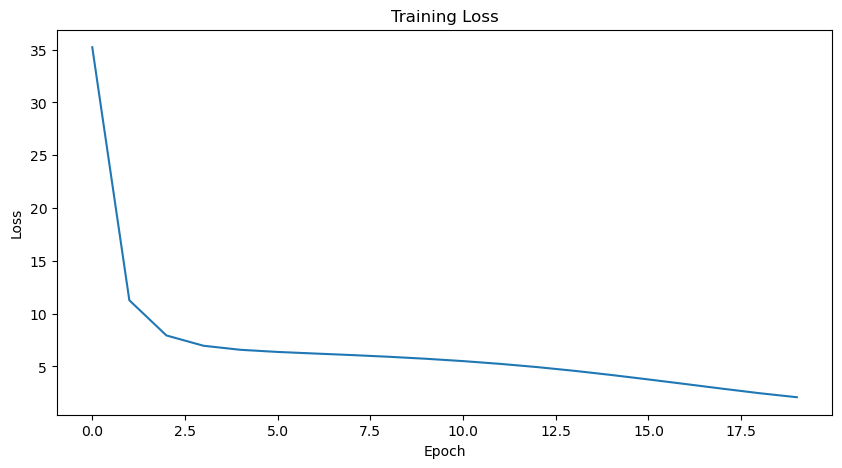

flow pid, normalized I_mxy, R: 0.1520794885664177, U1: 0.2915059925353818, U2: 0.4698679709483574, S: 0.08654654794984301


In [8]:
from pid.models import CartesianProductFlow
from pid.optimizers import flow_pid

def standardize_data(data):
    # standardize data along columns
    return (data - data.mean(dim=0, keepdim=True)) / data.std(dim=0, keepdim=True)

m_data_standardized = standardize_data(torch.tensor(m.T, dtype=torch.float32))
x_data_standardized = standardize_data(torch.tensor(x.T, dtype=torch.float32))
y_data_standardized = standardize_data(torch.tensor(y.T,dtype=torch.float32))

dataset = TensorDataset(x_data_standardized, y_data_standardized, m_data_standardized)
dataloader = DataLoader(dataset, batch_size=1000, shuffle=True)

###### flow pid ######
enable_cuda=True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
print(f"Using device: {device}")

model = CartesianProductFlow(
    dm=dm,
    dx=dx,
    dy=dy,
    n_flows=32,
).to(device)

pid_flows = flow_pid.fit_flows(model, dataloader, n_epochs=20, lr=2e-4, device=device, verbose=True)
ret = flow_pid.fit_pid(pid_flows, dataloader, device=device, verbose=True)
norm = ret[7] + ret[5] + ret[6] + ret[8]
print(f"flow pid, normalized I_mxy, R: {ret[7]/norm}, U1: {ret[5]/norm}, U2: {ret[6]/norm}, S: {ret[8]/norm}")